In [1]:
# ============================================================
# FEATURE ENGINEERING WITH BITCOIN DATA FROM THE COINGECKO API
# ============================================================
#
# This program does four main things:
#
# 1. Connects to the CoinGecko API
# 2. Downloads the last 180 days of Bitcoin price and volume data
# 3. Creates useful features for machine learning
# 4. Creates a target variable to predict whether Bitcoin
#    will go up or down the following day
#
# Feature engineering means creating useful new columns from
# existing data that can help a machine learning model learn.
# ============================================================


# ------------------------------------------------------------
# IMPORT LIBRARIES
# ------------------------------------------------------------

import requests
# requests allows Python to connect to websites and APIs.

import pandas as pd
# pandas is used to work with tables of data.
# We usually use "pd" as a shorter name for pandas.

import numpy as np
# numpy is used for numerical calculations.
# We use "np" as the shorter name.


# ============================================================
# STEP 1: DOWNLOAD BITCOIN DATA FROM COINGECKO
# ============================================================


# This is the URL for CoinGecko's Bitcoin market data API.
url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"


# These are the settings we send with our API request.
params = {
    "vs_currency": "usd",  # Get Bitcoin prices in US Dollars
    "days": "180",         # Get the last 180 days of data
    "interval": "daily"    # Get one data point per day
}


# requests.get() sends a request to the API.
# The API then sends data back to Python.
response = requests.get(url, params=params)


# raise_for_status() checks if the API request was successful.
# If there is an error, Python will display the error instead
# of continuing with incorrect or missing data.
response.raise_for_status()


# .json() converts the API response into Python data.
# The result is usually a dictionary containing lists.
data = response.json()


# ============================================================
# STEP 2: CREATE A PANDAS DATAFRAME
# ============================================================


# The API gives us price data in this format:
#
# [timestamp, price]
#
# Example:
# [1725148800000, 59000]
#
# pd.DataFrame() converts this data into a table.
prices = pd.DataFrame(
    data["prices"],
    columns=["timestamp", "Close"]
)

# "timestamp" = the date and time in milliseconds
# "Close" = the Bitcoin price


# The API gives us volume data in this format:
#
# [timestamp, volume]
#
# We also convert this into a DataFrame.
volumes = pd.DataFrame(
    data["total_volumes"],
    columns=["timestamp", "Volume"]
)

# "Volume" represents the amount of Bitcoin trading activity.


# ============================================================
# STEP 3: CONVERT THE TIMESTAMP INTO A REAL DATE
# ============================================================


# pd.to_datetime() converts timestamps into readable dates.
#
# unit="ms" means the timestamp is measured in milliseconds.
prices["Date"] = pd.to_datetime(
    prices["timestamp"],
    unit="ms"
)


# We do the same thing for the volume DataFrame.
volumes["Date"] = pd.to_datetime(
    volumes["timestamp"],
    unit="ms"
)


# ============================================================
# STEP 4: COMBINE PRICE AND VOLUME DATA
# ============================================================


# merge() combines two DataFrames together.
#
# We combine them using the "Date" column.
#
# on="Date" tells pandas which column to use when matching data.
df = prices.merge(
    volumes,
    on="Date"
)


# Select only the columns we want to keep.
#
# We do not need the original timestamp columns anymore.
df = df[["Date", "Close", "Volume"]]


# sort_values() puts the data in chronological order.
#
# ascending=True means oldest dates come first.
df = df.sort_values(
    "Date",
    ascending=True
)


# set_index() makes the Date column the index of the DataFrame.
#
# An index helps us work with time-series data.
df = df.set_index("Date")


# Display the first 5 rows of the original data.
#
# head() shows the first 5 rows by default.
print("RAW BITCOIN DATA")
print(df.head())


# ============================================================
# STEP 5: DAILY RETURN
# ============================================================


# pct_change() calculates the percentage change from one row
# to the next.
#
# Formula:
#
# (Today's Price - Yesterday's Price) / Yesterday's Price
#
# Example:
# Yesterday = $100
# Today = $110
#
# Return = 10%
df["daily_return"] = df["Close"].pct_change()


# ============================================================
# STEP 6: LOG RETURN
# ============================================================


# shift(1) moves the data down by one row.
#
# This allows us to compare today's price with yesterday's price.
#
# The formula below calculates the logarithmic return:
#
# log(Today's Price / Yesterday's Price)
#
# np.log() calculates the natural logarithm.
df["log_return"] = np.log(
    df["Close"] / df["Close"].shift(1)
)


# ============================================================
# STEP 7: MOVING AVERAGES
# ============================================================


# rolling(7) creates a moving window of 7 days.
#
# mean() calculates the average.
#
# This gives us the average Bitcoin price over the last 7 days.
df["ma_7"] = df["Close"].rolling(7).mean()


# Average Bitcoin price over the last 14 days.
df["ma_14"] = df["Close"].rolling(14).mean()


# Average Bitcoin price over the last 30 days.
df["ma_30"] = df["Close"].rolling(30).mean()


# ============================================================
# STEP 8: VOLATILITY
# ============================================================


# rolling(7).std() calculates the standard deviation
# of the last 7 prices.
#
# Standard deviation measures how much the prices are changing.
#
# A higher value generally means the market is more volatile.
df["volatility_7"] = df["Close"].rolling(7).std()


# Calculate volatility using the previous 14 days.
df["volatility_14"] = df["Close"].rolling(14).std()


# ============================================================
# STEP 9: VOLUME FEATURES
# ============================================================


# Calculate the percentage change in trading volume.
#
# pct_change() compares today's volume to yesterday's volume.
df["volume_change"] = df["Volume"].pct_change()


# Calculate the average trading volume over the last 7 days.
df["avg_volume_7"] = df["Volume"].rolling(7).mean()


# ============================================================
# STEP 10: VOLUME SPIKE
# ============================================================


# We want to identify unusually high trading volume.
#
# If today's volume is more than 1.5 times the average
# volume from the previous 7 days:
#
# volume_spike = 1
#
# Otherwise:
#
# volume_spike = 0
#
# np.where() works like an IF statement.
#
# Format:
#
# np.where(condition, value_if_true, value_if_false)
df["volume_spike"] = np.where(
    df["Volume"] > 1.5 * df["avg_volume_7"],
    1,
    0
)


# ============================================================
# STEP 11: RSI (RELATIVE STRENGTH INDEX)
# ============================================================


# diff() calculates the difference between today's closing
# price and yesterday's closing price.
#
# Positive number = price increased
# Negative number = price decreased
df["price_change"] = df["Close"].diff()


# Create a column containing only positive price changes.
#
# where() keeps the value when the condition is True.
#
# If the price change is not positive, we replace it with 0.
df["gain"] = df["price_change"].where(
    df["price_change"] > 0,
    0
)


# Create a column containing only price losses.
#
# First, we find negative price changes.
# Then we multiply by -1 to make the loss positive.
df["loss"] = -df["price_change"].where(
    df["price_change"] < 0,
    0
)


# Calculate the average gain over the last 14 days.
df["avg_gain"] = df["gain"].rolling(14).mean()


# Calculate the average loss over the last 14 days.
df["avg_loss"] = df["loss"].rolling(14).mean()


# Calculate Relative Strength (RS).
#
# RS = Average Gain / Average Loss
rs = df["avg_gain"] / df["avg_loss"]


# Calculate the 14-day RSI.
#
# RSI formula:
#
# RSI = 100 - (100 / (1 + RS))
#
# RSI generally ranges from 0 to 100.
#
# Higher RSI can suggest strong upward momentum.
# Lower RSI can suggest strong downward momentum.
df["rsi_14"] = 100 - (
    100 / (1 + rs)
)


# ============================================================
# STEP 12: LAG FEATURES
# ============================================================


# A lag feature gives us information from previous days.
#
# Lag features are useful for machine learning because
# today's market behavior may be influenced by previous data.


# Bitcoin closing price from 1 day ago.
df["close_lag_1"] = df["Close"].shift(1)


# Bitcoin closing price from 3 days ago.
df["close_lag_3"] = df["Close"].shift(3)


# Bitcoin closing price from 7 days ago.
df["close_lag_7"] = df["Close"].shift(7)


# Daily return from 1 day ago.
df["return_lag_1"] = df["daily_return"].shift(1)


# Daily return from 3 days ago.
df["return_lag_3"] = df["daily_return"].shift(3)


# ============================================================
# STEP 13: CREATE THE TARGET VARIABLE
# ============================================================


# Our machine learning model will try to predict:
#
# Will Bitcoin's price go UP tomorrow?
#
# 1 = Yes, the price goes up
# 0 = No, the price does not go up


# shift(-1) moves the Close price UP one row.
#
# This allows us to compare today's price with tomorrow's price.
df["price_up_tomorrow"] = np.where(
    df["Close"].shift(-1) > df["Close"],
    1,
    0
)


# ============================================================
# STEP 14: CLEAN THE DATA
# ============================================================


# Some rows contain missing values (NaN).
#
# This happens because:
#
# - pct_change() needs a previous day
# - moving averages need several days of data
# - lag features need previous days
# - tomorrow's price is unknown for the final row
#
# dropna() removes rows containing missing values.
df = df.dropna()


# ============================================================
# OPTIONAL: REMOVE INTERMEDIATE RSI COLUMNS
# ============================================================


# The following columns were only needed to calculate RSI.
#
# We remove them to keep our final machine learning dataset
# clean and simple.
df = df.drop(
    columns=[
        "price_change",
        "gain",
        "loss",
        "avg_gain",
        "avg_loss"
    ]
)


# ============================================================
# STEP 15: VIEW THE FINAL DATASET
# ============================================================


# Display the first 5 rows of the completed dataset.
print("\nFINAL FEATURE ENGINEERED DATASET")
print(df.head())


# Display all column names.
print("\nFINAL COLUMNS")
print(df.columns.tolist())


# Display the shape of the dataset.
#
# shape returns:
#
# (number of rows, number of columns)
print("\nDATASET SHAPE")
print(df.shape)

RAW BITCOIN DATA
                   Close        Volume
Date                                  
2026-03-06  70868.218196  4.752440e+10
2026-03-07  68142.883124  3.912386e+10
2026-03-08  67339.674401  2.180068e+10
2026-03-09  66042.751079  3.023331e+10
2026-03-10  68430.609260  4.365803e+10

FINAL FEATURE ENGINEERED DATASET
                   Close        Volume  daily_return  log_return  \
Date                                                               
2026-04-04  66822.552303  2.788170e+10     -0.000971   -0.000972   
2026-04-05  67077.150053  1.834940e+10      0.003810    0.003803   
2026-04-06  69002.038479  2.385975e+10      0.028697    0.028293   
2026-04-07  68672.246575  4.686653e+10     -0.004779   -0.004791   
2026-04-08  71661.763724  5.911462e+10      0.043533    0.042612   

                    ma_7         ma_14         ma_30  volatility_7  \
Date                                                                 
2026-04-04  66972.080088  68074.204420  69314.915383    792

RAW BITCOIN DATA
                   Close        Volume
Date                                  
2026-03-06  70868.218196  4.752440e+10
2026-03-07  68142.883124  3.912386e+10
2026-03-08  67339.674401  2.180068e+10
2026-03-09  66042.751079  3.023331e+10
2026-03-10  68430.609260  4.365803e+10

FEATURE ENGINEERED DATA
                   Close        Volume  daily_return          ma_7  \
Date                                                                 
2026-04-04  66822.552303  2.788170e+10     -0.000971  66972.080088   
2026-04-05  67077.150053  1.834940e+10      0.003810  67070.409459   
2026-04-06  69002.038479  2.385975e+10      0.028697  67506.838966   
2026-04-07  68672.246575  4.686653e+10     -0.004779  67789.835409   
2026-04-08  71661.763724  5.911462e+10      0.043533  68297.591003   

                   ma_30  volatility_14     rsi_14  
Date                                                
2026-04-04  69314.915383    1771.966850  38.279044  
2026-04-05  69188.546445    1788.00

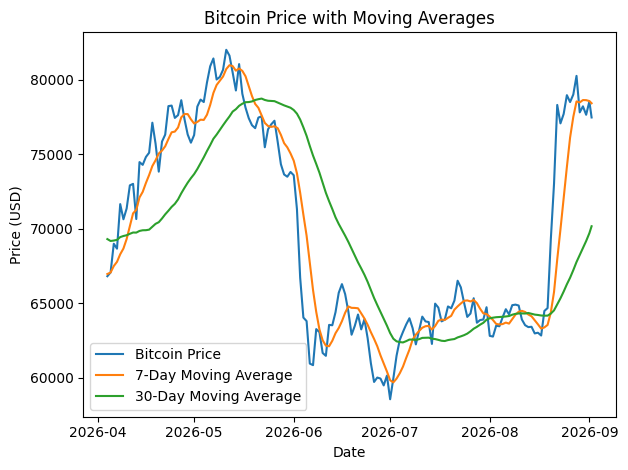

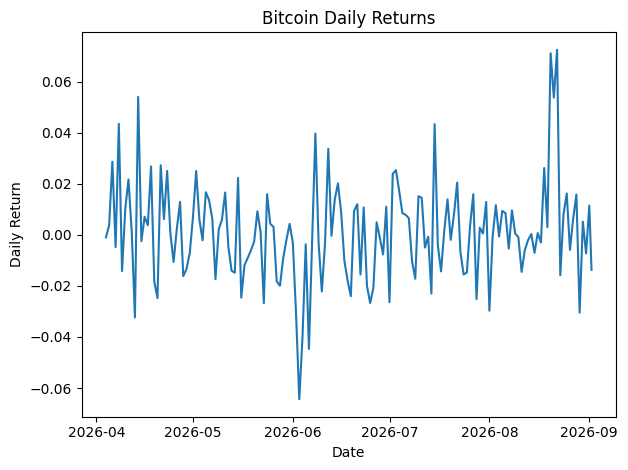

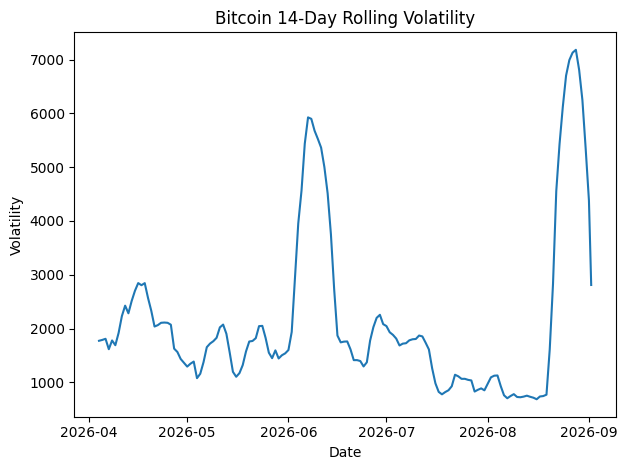

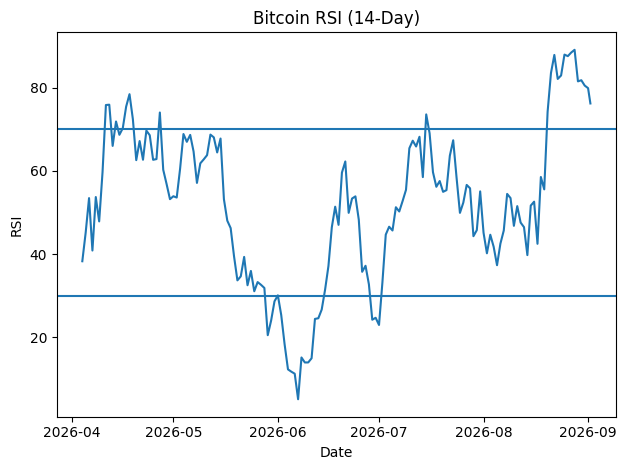


FINAL COLUMNS:
['Close', 'Volume', 'daily_return', 'ma_7', 'ma_30', 'volatility_14', 'rsi_14']

DATASET SHAPE:
(152, 7)


In [1]:
# ============================================================
# BITCOIN DATA: FEATURE ENGINEERING + DATA VISUALIZATION
# ============================================================
#
# This program builds on our previous feature engineering code.
#
# It does four main things:
#
# 1. Downloads Bitcoin data from the CoinGecko API
# 2. Creates useful financial features
# 3. Cleans the data
# 4. Creates visualizations to better understand the data
#
# We will visualize:
#
# - Bitcoin price and moving averages
# - Daily returns
# - Market volatility
# - RSI (Relative Strength Index)
#
# ============================================================


# ------------------------------------------------------------
# IMPORT LIBRARIES
# ------------------------------------------------------------

import requests
# requests allows Python to connect to APIs and download data.

import pandas as pd
# pandas allows us to organize and analyze data using DataFrames.

import numpy as np
# numpy is used for numerical calculations.

import matplotlib.pyplot as plt
# matplotlib.pyplot is used to create charts and visualizations.
#
# We use "plt" as a shorter name.


# ============================================================
# STEP 1: DOWNLOAD BITCOIN DATA FROM COINGECKO
# ============================================================


# This is the CoinGecko API URL.
#
# We are specifically requesting data for Bitcoin.
url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"


# These parameters tell the API what data we want.
params = {

    # Get Bitcoin prices in US Dollars.
    "vs_currency": "usd",

    # Get the last 180 days of data.
    "days": "180",

    # Return the data using daily intervals.
    "interval": "daily"
}


# requests.get() sends a request to the CoinGecko API.
#
# The API will send the Bitcoin data back to Python.
response = requests.get(url, params=params)


# raise_for_status() checks whether the API request worked.
#
# If the API returns an error, Python will stop and display
# information about the problem.
response.raise_for_status()


# .json() converts the API response into Python data.
#
# The result will contain dictionaries and lists that we can
# work with in Python.
data = response.json()


# ============================================================
# STEP 2: CREATE DATAFRAMES
# ============================================================


# The price data from CoinGecko looks similar to this:
#
# [timestamp, price]
#
# We convert the price data into a pandas DataFrame.
prices = pd.DataFrame(
    data["prices"],
    columns=["timestamp", "Close"]
)


# The volume data looks similar to this:
#
# [timestamp, volume]
#
# We convert the volume data into another DataFrame.
volumes = pd.DataFrame(
    data["total_volumes"],
    columns=["timestamp", "Volume"]
)


# ============================================================
# STEP 3: CONVERT TIMESTAMPS INTO DATES
# ============================================================


# The API provides timestamps in milliseconds.
#
# pd.to_datetime() converts those timestamps into readable dates.
#
# unit="ms" tells pandas that the timestamps are in milliseconds.
prices["Date"] = pd.to_datetime(
    prices["timestamp"],
    unit="ms"
)


# Convert the volume timestamps into dates as well.
volumes["Date"] = pd.to_datetime(
    volumes["timestamp"],
    unit="ms"
)


# ============================================================
# STEP 4: COMBINE PRICE AND VOLUME DATA
# ============================================================


# merge() combines two DataFrames.
#
# We combine the price and volume DataFrames using the Date column.
df = prices.merge(
    volumes,
    on="Date"
)


# Keep only the columns we need.
#
# The timestamp columns are no longer needed.
df = df[["Date", "Close", "Volume"]]


# sort_values() organizes the data by date.
#
# Oldest dates will appear first.
df = df.sort_values("Date")


# set_index() makes the Date column the index.
#
# This is useful when working with time-series data
# and when creating charts.
df = df.set_index("Date")


# Display the first five rows of the raw data.
#
# head() shows the first five rows by default.
print("RAW BITCOIN DATA")
print(df.head())


# ============================================================
# STEP 5: FEATURE ENGINEERING
# ============================================================
#
# Feature engineering means creating new columns that provide
# useful information for data analysis or machine learning.
#
# We will create:
#
# - Daily returns
# - Moving averages
# - Volatility
# - RSI
#
# ============================================================


# ------------------------------------------------------------
# DAILY RETURNS
# ------------------------------------------------------------


# pct_change() calculates the percentage change between
# today's price and the previous day's price.
#
# Example:
#
# Yesterday = $100
# Today = $105
#
# Daily Return = 5%
df["daily_return"] = df["Close"].pct_change()


# ------------------------------------------------------------
# MOVING AVERAGES
# ------------------------------------------------------------


# rolling(7) creates a window containing the previous 7 rows.
#
# mean() calculates the average value inside that window.
#
# This creates a 7-day moving average.
df["ma_7"] = df["Close"].rolling(7).mean()


# This creates a 30-day moving average.
#
# Longer moving averages are smoother and react more slowly
# to recent price changes.
df["ma_30"] = df["Close"].rolling(30).mean()


# ------------------------------------------------------------
# VOLATILITY
# ------------------------------------------------------------


# rolling(14) looks at the previous 14 days.
#
# std() calculates the standard deviation.
#
# Standard deviation tells us how much the prices are moving
# away from their average.
#
# Higher volatility generally means larger price movements.
df["volatility_14"] = df["Close"].rolling(14).std()


# ============================================================
# STEP 6: RSI (RELATIVE STRENGTH INDEX)
# ============================================================


# diff() calculates the difference between today's closing
# price and yesterday's closing price.
#
# Positive number = price increased
# Negative number = price decreased
delta = df["Close"].diff()


# where() keeps the price change when it is positive.
#
# If the price change is negative, we replace it with 0.
#
# This gives us a series containing only gains.
gain = delta.where(
    delta > 0,
    0
)


# This finds negative price changes.
#
# The negative sign (-) turns losses into positive numbers.
#
# Example:
#
# Price change = -100
#
# Loss = 100
loss = -delta.where(
    delta < 0,
    0
)


# Calculate the average gain over the previous 14 days.
avg_gain = gain.rolling(14).mean()


# Calculate the average loss over the previous 14 days.
avg_loss = loss.rolling(14).mean()


# Calculate Relative Strength (RS).
#
# Formula:
#
# RS = Average Gain / Average Loss
rs = avg_gain / avg_loss


# Calculate the 14-day RSI.
#
# Formula:
#
# RSI = 100 - (100 / (1 + RS))
#
# RSI normally ranges between 0 and 100.
df["rsi_14"] = 100 - (
    100 / (1 + rs)
)


# ============================================================
# STEP 7: CLEAN THE DATA
# ============================================================


# Some rows contain NaN (missing values).
#
# This happens because moving averages, volatility, and RSI
# need data from previous days before they can be calculated.
#
# dropna() removes rows containing missing values.
df = df.dropna()


# Display the cleaned dataset.
print("\nFEATURE ENGINEERED DATA")
print(df.head())


# ============================================================
# VISUALIZATION 1:
# BITCOIN PRICE VS MOVING AVERAGES
# ============================================================


# plt.figure() creates a new chart.
#
# We create a new figure for every visualization.
plt.figure()


# plt.plot() creates a line chart.
#
# df.index contains our dates.
#
# df["Close"] contains Bitcoin prices.
plt.plot(
    df.index,
    df["Close"],
    label="Bitcoin Price"
)


# Plot the 7-day moving average.
plt.plot(
    df.index,
    df["ma_7"],
    label="7-Day Moving Average"
)


# Plot the 30-day moving average.
plt.plot(
    df.index,
    df["ma_30"],
    label="30-Day Moving Average"
)


# Add a title to the chart.
plt.title("Bitcoin Price with Moving Averages")


# Label the X-axis.
plt.xlabel("Date")


# Label the Y-axis.
plt.ylabel("Price (USD)")


# legend() displays the labels for each line.
plt.legend()


# tight_layout() helps prevent chart elements from overlapping.
plt.tight_layout()


# show() displays the chart.
plt.show()


# ------------------------------------------------------------
# TEACHING POINT:
#
# Moving averages smooth out daily price fluctuations.
#
# They can help us identify the overall market trend.
#
# The shorter 7-day moving average reacts faster.
#
# The longer 30-day moving average reacts more slowly.
# ------------------------------------------------------------


# ============================================================
# VISUALIZATION 2:
# DAILY RETURNS
# ============================================================


# Create a new chart.
plt.figure()


# Plot the daily percentage returns.
plt.plot(
    df.index,
    df["daily_return"]
)


# Add a title.
plt.title("Bitcoin Daily Returns")


# Label the X-axis.
plt.xlabel("Date")


# Label the Y-axis.
plt.ylabel("Daily Return")


# Adjust spacing.
plt.tight_layout()


# Display the chart.
plt.show()


# ------------------------------------------------------------
# TEACHING POINT:
#
# Price tells us the dollar value of Bitcoin.
#
# Returns tell us how much the price changed relative
# to the previous day.
#
# Financial models often use returns instead of raw prices
# because returns make different assets easier to compare.
# ------------------------------------------------------------


# ============================================================
# VISUALIZATION 3:
# 14-DAY ROLLING VOLATILITY
# ============================================================


# Create a new chart.
plt.figure()


# Plot the 14-day rolling volatility.
plt.plot(
    df.index,
    df["volatility_14"]
)


# Add a title.
plt.title("Bitcoin 14-Day Rolling Volatility")


# Label the X-axis.
plt.xlabel("Date")


# Label the Y-axis.
plt.ylabel("Volatility")


# Adjust spacing.
plt.tight_layout()


# Display the chart.
plt.show()


# ------------------------------------------------------------
# TEACHING POINT:
#
# Volatility measures how much prices are changing.
#
# Higher volatility can indicate:
#
# - More uncertainty
# - Larger price movements
# - Higher potential risk
#
# Lower volatility generally means prices are moving
# more consistently.
# ------------------------------------------------------------


# ============================================================
# VISUALIZATION 4:
# RSI (RELATIVE STRENGTH INDEX)
# ============================================================


# Create a new chart.
plt.figure()


# Plot the RSI values.
plt.plot(
    df.index,
    df["rsi_14"]
)


# axhline() creates a horizontal line.
#
# We create a line at RSI = 70.
plt.axhline(70)


# Create another horizontal line at RSI = 30.
plt.axhline(30)


# Add a title.
plt.title("Bitcoin RSI (14-Day)")


# Label the X-axis.
plt.xlabel("Date")


# Label the Y-axis.
plt.ylabel("RSI")


# Adjust spacing.
plt.tight_layout()


# Display the chart.
plt.show()


# ------------------------------------------------------------
# TEACHING POINT:
#
# RSI measures market momentum.
#
# RSI values generally range from 0 to 100.
#
# RSI above 70 can sometimes indicate that an asset
# has experienced strong upward momentum.
#
# RSI below 30 can sometimes indicate that an asset
# has experienced strong downward momentum.
#
# IMPORTANT:
#
# RSI is not a guarantee that the price will reverse.
# It is simply one indicator that traders and analysts
# can use along with other information.
# ------------------------------------------------------------


# ============================================================
# FINAL DATASET INFORMATION
# ============================================================


# Display the names of all columns in the final dataset.
print("\nFINAL COLUMNS:")
print(df.columns.tolist())


# Display the number of rows and columns.
#
# shape returns:
#
# (number of rows, number of columns)
print("\nDATASET SHAPE:")
print(df.shape)